In [10]:
import torch
import re
import easyocr
import numpy as np
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed").to(device)

detector = easyocr.Reader(['en'], gpu=(device == 'cuda'))

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


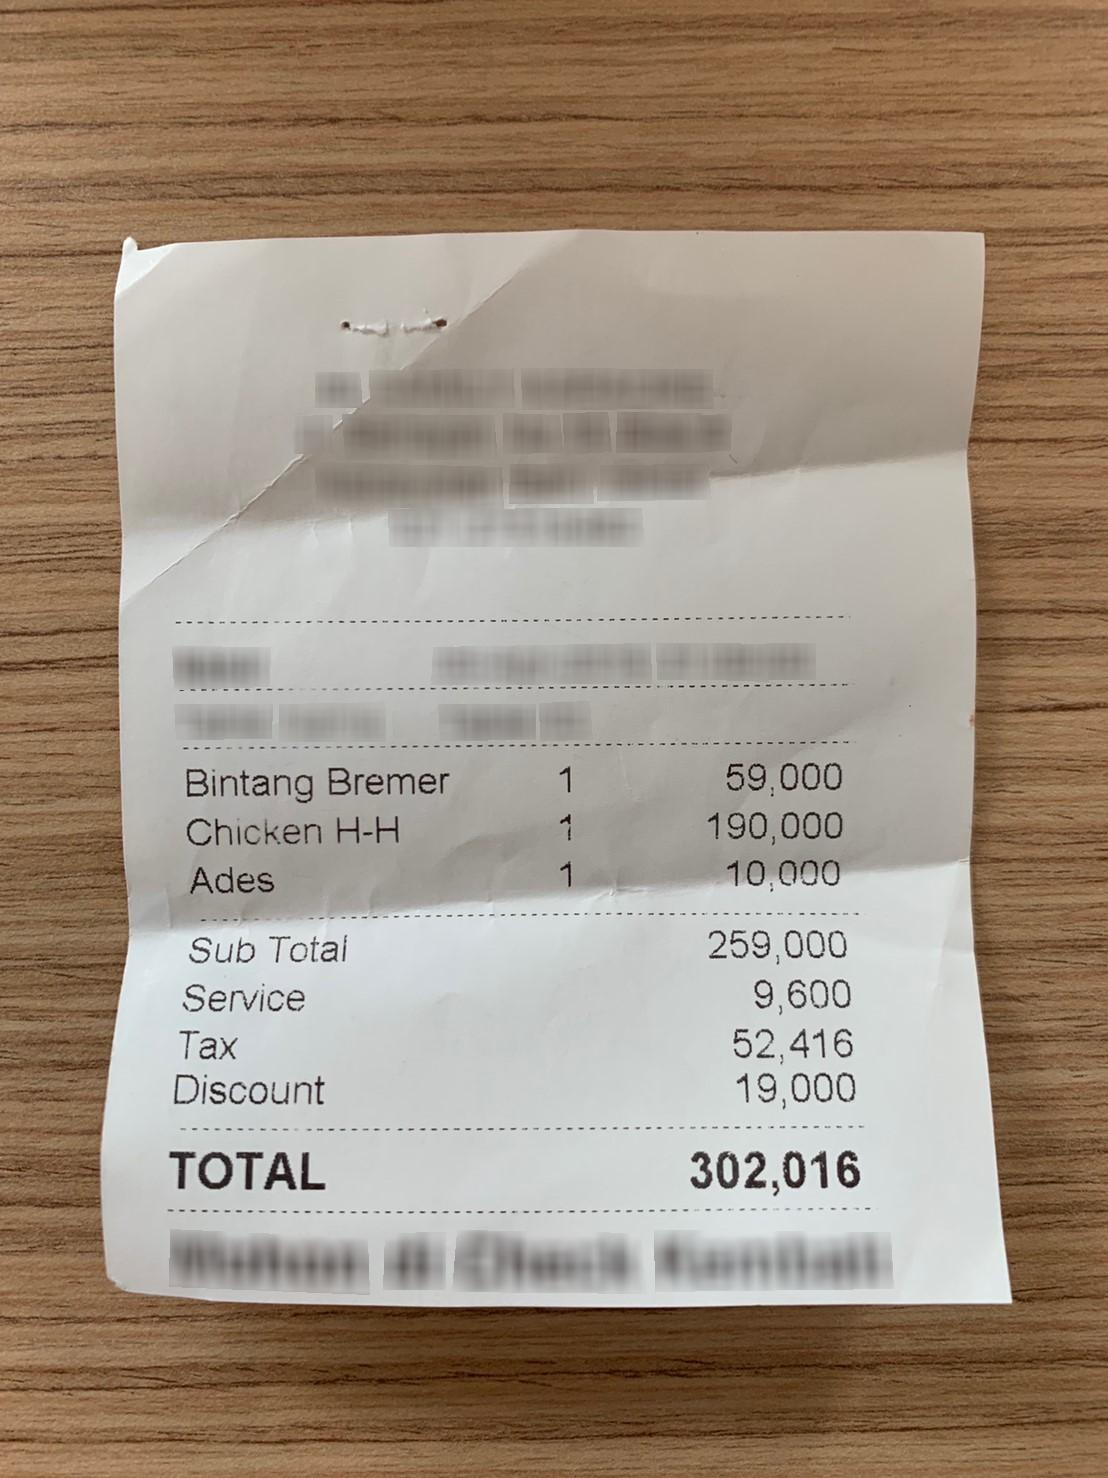

In [12]:
image_path = "receipt1.jpg"
img = Image.open(image_path).convert("RGB")

img

In [13]:
img_array = np.array(img)

detections = detector.readtext(img_array)

line_crops = []

for (bbox, text, prob) in detections:
    top_left = bbox[0]
    bottom_right = bbox[2]

    crop = img.crop((
        int(top_left[0]),
        int(top_left[1]),
        int(bottom_right[0]),
        int(bottom_right[1])
    ))

    line_crops.append(crop)

print("Detected lines:", len(line_crops))

Detected lines: 17


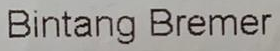

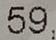

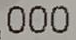

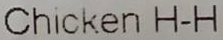

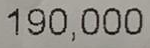

In [16]:
for crop in line_crops[:5]:
    display(crop)

In [17]:
texts = []
for crop in line_crops:
    pixel_values = processor(images=crop, return_tensors="pt").pixel_values.to(device)
    
    generated_ids = model.generate(pixel_values)
    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    texts.append(text)

texts

['BINTANG BREMER',
 '59,',
 '000',
 'CHICKEN H-H',
 '190,000',
 'ADES',
 '10,000',
 'SUB TOTAL',
 '259,000',
 'SERVICE',
 '9,600',
 'TAX',
 '52,416',
 'DISCOUNT',
 '19,000',
 'TOTAL',
 '302,016']

In [7]:
def extract_price(text):
    clean_str = re.sub(r'[^\d]', '', text)
    return float(clean_str) if clean_str else 0.0


items = []
total = 0

i = 0
while i < len(texts):

    line = texts[i].strip()

    if "TOTAL" in line.upper():
        if i + 1 < len(texts):
            total = extract_price(texts[i+1])
        break

    if i + 1 < len(texts):
        price = extract_price(texts[i+1])

        if price > 0:
            items.append({
                "name": line,
                "price": price
            })
            i += 2
            continue

    i += 1

print("Items:", items)
print("Total:", total)

Items: [{'name': 'MOSMINE MT', 'price': 24000.0}, {'name': 'OCONUT JELLY', 'price': 4000.0}]
Total: 28000.0


In [8]:
import time

start = time.time()

for crop in line_crops:
    pixel_values = processor(images=crop, return_tensors="pt").pixel_values.to(device)
    model.generate(pixel_values)

end = time.time()

print("Inference time:", end-start, "seconds")

Inference time: 1.6675465106964111 seconds
